# Exercise 1 — Linear Regression


## Part A: Understanding LR

Imagine we have data from a small restaurant.

For each table, we know:

- the total bill
- the tip left by the customer

We want to predict the tip from the bill using a straight line:

`predicted tip = weight × bill + bias`

Your task is to change `weight` and `bias` until the line fits the data as well as possible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample restaurant data
# x = total bill in dollars
# y = tip in dollars

x = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40, 45])

y = np.array([1.8, 2.0, 2.7, 3.0, 3.6, 3.5, 4.2, 4.8, 5.0, 5.8, 6.5, 7.0])

Matplotlib is building the font cache; this may take a moment.


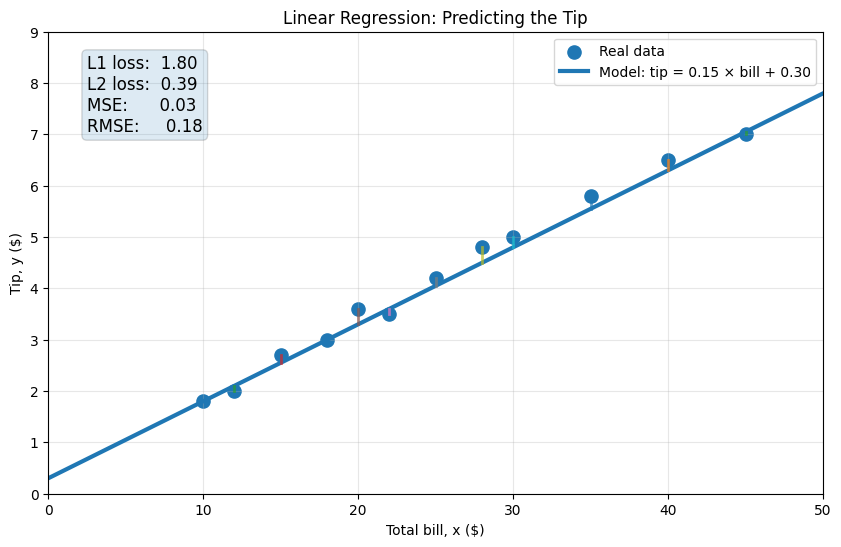

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sample restaurant data
# x = total bill in dollars
# y = tip in dollars

x = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40, 45])

y = np.array([1.8, 2.0, 2.7, 3.0, 3.6, 3.5, 4.2, 4.8, 5.0, 5.8, 6.5, 7.0])
weight = 0.15
bias = 0.3
# Predictions
y_pred = weight * x + bias

# Residuals and losses
residuals = y - y_pred

l1 = np.sum(np.abs(residuals))
l2 = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=90, label="Real data")

# Regression line
x_line = np.linspace(0, 50, 100)
y_line = weight * x_line + bias

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label=f"Model: tip = {weight:.2f} × bill + {bias:.2f}"
)

# Residual lines
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], linewidth=2, alpha=0.7)

plt.title("Linear Regression: Predicting the Tip")
plt.xlabel("Total bill, x ($)")
plt.ylabel("Tip, y ($)")

plt.xlim(0, 50)
plt.ylim(0, 9)
plt.grid(True, alpha=0.3)
plt.legend()

loss_text = (
    f"L1 loss:  {l1:.2f}\n"
    f"L2 loss:  {l2:.2f}\n"
    f"MSE:      {mse:.2f}\n"
    f"RMSE:     {rmse:.2f}"
)

plt.text(
    0.05,
    0.95,
    loss_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
    fontsize=12
)

plt.show()

### Your task

Change the values of `weight` and `bias`, then rerun the cell.

Try to make the line fit the points as well as possible.

Questions:

1. What is the lowest MSE you can find? 
2. Which values of `weight` and `bias` gave you that MSE?
3. What happens to the residual lines when the model improves?
4. What does the `weight` mean in this example?
5. What does the `bias` mean?

1.  Lowest MSE i can find is 0.021
2.  I gave 0.15 weight and 0.3 bias
3.  Residual lines shortens drastically when the model improves
4.  The weight in this example represent how the line goes up/down and at what rate
5.  The bias is the amount of tip u receive when the bill is 0.

In [ ]:
# Compute the best linear regression solution automatically

best_weight, best_bias = np.polyfit(x, y, 1)

y_best = best_weight * x + best_bias
best_mse = np.mean((y - y_best) ** 2)
best_rmse = np.sqrt(best_mse)

print(f"Best weight: {best_weight:.3f}")
print(f"Best bias:   {best_bias:.3f}")
print(f"Best MSE:    {best_mse:.3f}")
print(f"Best RMSE:   {best_rmse:.3f}")

Best weight: 0.154
Best bias:   0.315
Best MSE:    0.019
Best RMSE:   0.139


## Part B: Use a real dataset

In the previous exercise, we used (unexisting) sample data.

Now choose one real dataset and repeat the same process:

1. Load the dataset.
2. Choose one numerical column as `x`.
3. Choose one numerical column as `y`.
4. Fit a line manually by changing `weight` and `bias`.
5. Compute the residuals, MSE, and RMSE.
6. Compare your manual line with the best line found by Python.

The model is always:

`y_pred = weight * x + bias`

### Option 1 — Student performance dataset from Hugging Face

This one is probably closest to your idea:

> Can we predict exam score from study hours?

The Hugging Face dataset `krishal07/student-performance` includes columns such as `StudyHours`, `TestScore_Math`, `TestScore_Reading`, `TestScore_Science`, `GPA`, and `AttendanceRate`.  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("krishal07/student-performance", split="train")

df = dataset.to_pandas()
df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,17,12,Female,White,3,HS,Public,Suburban,70.258235,79.665185,...,2.743879,0.906809,1.089243,1,1,0,0,0,2,2
1,18,12,Female,White,2,HS,Public,Suburban,67.876546,59.611505,...,2.587700,0.843739,0.879911,1,1,0,1,0,5,2
2,16,11,Female,White,2,HS,Public,City,62.070623,70.577443,...,2.426294,0.850923,1.003442,1,1,0,1,1,5,1
3,14,9,Female,White,4,Bachelors+,Public,Town,79.909312,82.924450,...,3.558240,0.946786,1.814810,1,1,0,1,0,4,2
4,16,11,Female,Two-or-more,4,SomeCollege,Public,Rural,90.562294,95.352336,...,3.896884,0.988036,1.157241,1,1,0,0,0,3,4


Manual MSE: 303.77337950392575
Manual RMSE: 17.429095774133717
Best weight (Python): 13.036552574315083
Best bias (Python): 61.94255826450434
Best possible MSE: 78.30716481095737


C:\Users\caoch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


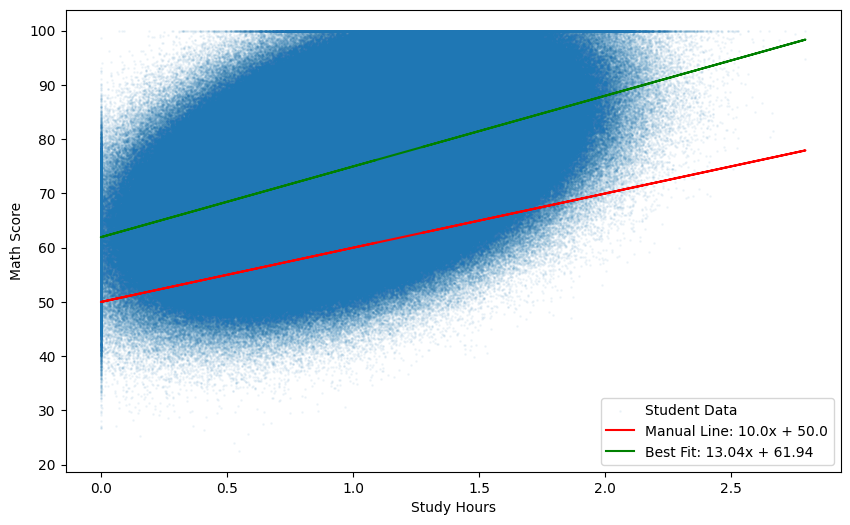

Manual MSE: 303.77337950392575
Manual RMSE: 17.429095774133717
Best weight (Python): 13.036552574315083
Best bias (Python): 61.94255826450434
Best possible MSE: 78.30716481095737


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("krishal07/student-performance", split="train")

df = dataset.to_pandas()
df.head()

x = df["StudyHours"].to_numpy()
y = df["TestScore_Math"].to_numpy()
#Manual Fitting
w_guess = 10.0  
b_guess = 50.0  
y_pred = w_guess*x + b_guess

#Compute Errors
residuals = y - y_pred
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

print(f"Manual MSE: {mse}")
print(f"Manual RMSE: {rmse}")

#Python's Best Fit
w_best, b_best = np.polyfit(x, y, 1)
print(f"Best weight (Python): {w_best}")
print(f"Best bias (Python): {b_best}")

#Compute Best MSE
y_pred_best = w_best*x + b_best
mse_best = np.mean((y - y_pred_best)**2)
print(f"Best possible MSE: {mse_best}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.05, s=1, label="Student Data")

# Manual Fitting
w_guess = 10.0  
b_guess = 50.0  
y_pred = w_guess * x + b_guess
plt.plot(x, y_pred, color='red', label=f"Manual Line: {w_guess}x + {b_guess}")

# Compute Errors
mse = np.mean((y - y_pred)**2)
rmse = np.sqrt(mse)

# Python Best Fit
w_best, b_best = np.polyfit(x, y, 1)
y_pred_best = w_best * x + b_best
mse_best = np.mean((y - y_pred_best)**2)

# Plot Best Fit
plt.plot(x, y_pred_best, color='green', label=f"Best Fit: {w_best:.2f}x + {b_best:.2f}")

plt.xlabel("Study Hours")
plt.ylabel("Math Score")
plt.legend()
plt.show()

print(f"Manual MSE: {mse}")
print(f"Manual RMSE: {rmse}")
print(f"Best weight (Python): {w_best}")
print(f"Best bias (Python): {b_best}")
print(f"Best possible MSE: {mse_best}")

In [ ]:
# Question:
# Can we predict math test score from study hours?
# Yes, we can. Based on the data, the model indicates a positive link between study hours and math scores.
x = df["StudyHours"].to_numpy()
y = df["TestScore_Math"].to_numpy()

print("Number of students:", len(x))
print("First 5 study-hour values:", x[:5])
print("First 5 math scores:", y[:5])

Number of students: 8000774
First 5 study-hour values: [1.08924319 0.87991072 1.00344238 1.81481015 1.15724067]
First 5 math scores: [70.25823548 67.87654582 62.07062326 79.90931215 90.56229366]


#### Questions

1. Does more study time usually mean a higher test score?
2. Is the relationship perfectly linear?
3. Are there students with high study time but lower scores?
4. What other variables might help predict exam score?

1. Yes, with weight positive, we can see a clear upward trend. Study more hours
usualy goes with higher scores.
2. No, it is rarely perfect. MSE of about 78 shows that there is significant variance.
3. Yes, in this big dataset, there are student who spend alot of time study but got low score, and also high score student with little study time.
4. We should also consider attendance rate, or parent influence for better predictions, since in real life they strongly affect student performance as well

### Option 3 — Tips dataset

This is simple and easy to understand:

> Can we predict the tip from the total bill?

The `seaborn-data` repository provides sample datasets used in `seaborn` examples, including `tips.csv`.  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#load the dataset 
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Number of tables: 244
First 5 bills: [16.99 10.34 21.01 23.68 24.59]
First 5 tips: [1.01 1.66 3.5  3.31 3.61]


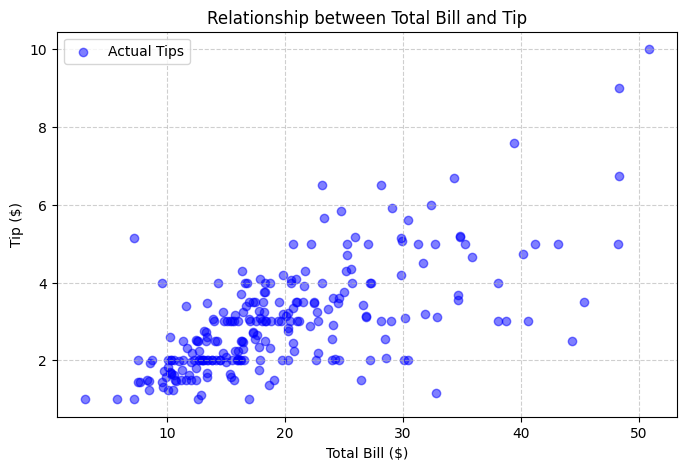

--- MANUAL LINE ---
Equation: y = 0.15 * x + 0.5
RMSE: 1.1900

--- PYTHON BEST FIT ---
Equation: y = 0.1050 * x + 0.9203
RMSE: 1.0179


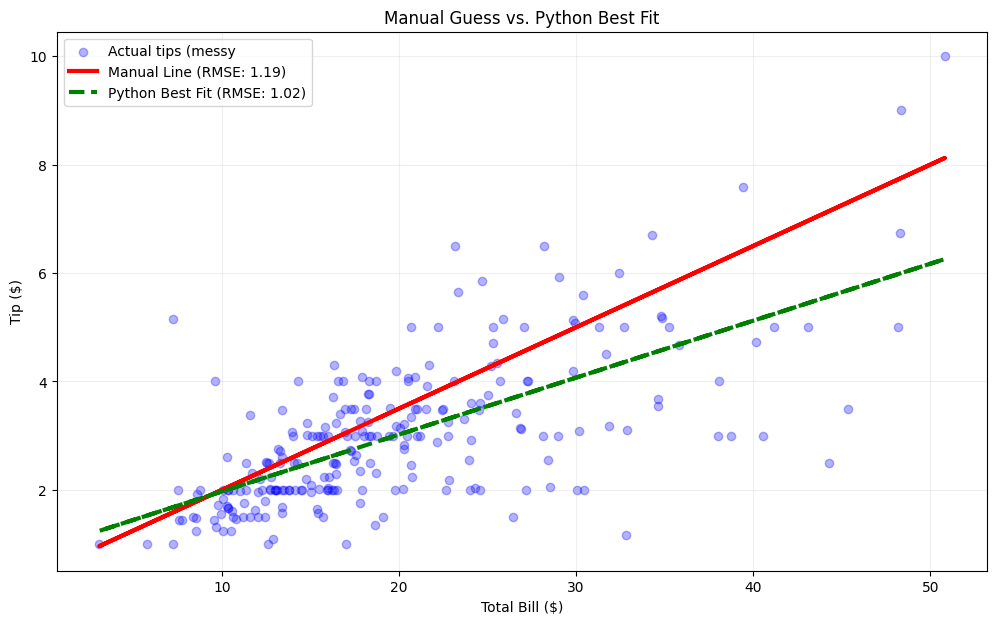

In [18]:
# Question:
# Can we predict the tip from the total bill?
#choose x and y  
x = df["total_bill"].to_numpy()
y = df["tip"].to_numpy()

print("Number of tables:", len(x))
print("First 5 bills:", x[:5])
print("First 5 tips:", y[:5])

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, color='blue', label='Actual Tips')

plt.title('Relationship between Total Bill and Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

# 2. Choose numerical columns for x and y
x = df["total_bill"].to_numpy()
y = df["tip"].to_numpy()

# 3. MANUAL FIT: Change these two numbers to try and beat Python!
weight_manual = 0.15 
bias_manual = 0.5    

y_pred_manual = weight_manual * x + bias_manual

# 4. PYTHON BEST FIT: The mathematical "perfect" line
weight_best, bias_best = np.polyfit(x, y, 1)
y_pred_best = weight_best * x + bias_best

# 5. Compute Metrics (Loss)
mse_manual = np.mean((y - y_pred_manual)**2)
rmse_manual = np.sqrt(mse_manual)

mse_best = np.mean((y - y_pred_best)**2)
rmse_best = np.sqrt(mse_best)

# 6. Plotting the results
plt.figure(figsize=(12, 7))

# Scatter plot of all 244 points (using alpha to handle the "messy" data)
plt.scatter(x, y, color='blue', alpha=0.3, label="Actual tips (messy")

# Draw the Manual Line
plt.plot(x, y_pred_manual, color='red', linewidth=3, label=f"Manual Line (RMSE: {rmse_manual:.2f})")

# Draw the Python Best Fit Line
plt.plot(x, y_pred_best, color='green', linestyle='--', linewidth=3, label=f"Python Best Fit (RMSE: {rmse_best:.2f})")

plt.title("Manual Guess vs. Python Best Fit")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend()
plt.grid(True, alpha=0.2)

# Print comparison text
print(f"--- MANUAL LINE ---")
print(f"Equation: y = {weight_manual} * x + {bias_manual}")
print(f"RMSE: {rmse_manual:.4f}")
print(f"\n--- PYTHON BEST FIT ---")
print(f"Equation: y = {weight_best:.4f} * x + {bias_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
plt.show()

#### Questions

1. Does a larger bill usually mean a larger tip?
2. What does the weight mean in this example?
3. Can one line explain all tipping behavior?
4. What other variables might help?

1. A larger bill usually means a larger tip
2. Weight mean in this example show how the graph change and the rate that it changes
3. One line absolutely cannot explain all tipping behavious
4. Other variables that might help: day of the week, hour of the day, even quality of service